# 07 — Expected Loss (EL = PD × EAD × LGD)

**Objective:** Combine the three component models into a per-loan Expected Loss estimate, then evaluate at the portfolio level.

**Formula:** `EL = PD × EAD% × LGD × loan_amnt`

**Models used:**
- **PD** — XGBoost, Test AUC 0.7251 ([notebook 04](04_pd_model.ipynb))
- **EAD** — Mean-by-term lookup ([notebook 05](05_ead_model.ipynb))
- **LGD** — Tuned LightGBM, Test R² 0.0095 ([notebook 06](06_lgd_model.ipynb))

**Population:** Loans issued 2016–2017 (the shared test vintage). We rebuild this population **once**, fresh from `df_model_raw.csv`, and score all three models against the exact same rows — no reuse of `test.csv`/`test_fe.csv`, which were each built via slightly different pipelines (PD's own feature-selected encoding vs. EAD/LGD's fuller one-hot encoding). Scoring from one consistent dataframe avoids row-alignment bugs between models.

**Caveat:** The original one-hot/target encoders from notebooks 04 and 06 weren't persisted to disk, only the trained models and their expected feature lists. This notebook reconstructs the encoding logic (same formulas, same train-fit statistics) rather than replaying a saved encoder object. Where this could introduce small approximation error — e.g. which category `pd.get_dummies` treats as the dropped reference — the code sidesteps it by encoding to full dummy sets and reindexing to each model's known feature list, rather than relying on `drop_first` matching exactly.

**Exposure basis:** `loan_amnt` is used as the EL exposure base (the model's `funded_amnt` field was dropped early as redundant with `loan_amnt`; the two are nearly identical in this dataset).

**Validation:** Compare total predicted portfolio EL against total realized loss among loans that actually defaulted in the test period — a sanity check, not a training signal.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Load Saved Models & Artifacts

In [35]:
pd_model = joblib.load('../models/pd_model.joblib')
pd_features = pd.read_csv('../models/pd_feature_names.csv')['feature'].tolist()

with open('../models/ead_model.json') as f:
    ead_artifact = json.load(f)
ead_lookup = {int(k): float(v) for k, v in ead_artifact['lookup'].items()}

lgd_model = joblib.load('../models/lgd_model.joblib')
lgd_features = pd.read_csv('../models/lgd_feature_names.csv')['feature'].tolist()

print(f"PD model:  {type(pd_model).__name__}, {len(pd_features)} features")
print(f"EAD model: term lookup -> {ead_lookup}")
print(f"LGD model: {type(lgd_model).__name__}, {len(lgd_features)} features")

PD model:  XGBClassifier, 58 features
EAD model: term lookup -> {36: 0.5804732715289598, 60: 0.7348155329774531}
LGD model: LGBMRegressor, 90 features


## 2. Rebuild the Test Population From Raw Data

Same base cleaning as notebooks 05/06 (which themselves mirror notebook 02), but **without** filtering to `default == 1` — we need every loan in the test vintage, since EL is an unconditional expectation across the whole portfolio, not just realized defaults.

In [36]:
df = pd.read_csv('../data/df_model_raw.csv', low_memory=False)

df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d_parsed'].dt.year
df['issue_month'] = df['issue_d_parsed'].dt.month

# Keep ALL loans (not just defaults), exclude 2018 (right-censored)
df = df[df['issue_year'] <= 2017].copy()

# Targets — only meaningful for rows that actually defaulted, kept for later validation
df['ead_pct'] = ((df['funded_amnt'] - df['total_rec_prncp']) / df['funded_amnt']).clip(0, 1)
df['lgd'] = (1 - (df['recoveries'] / df['funded_amnt']).clip(0, 1)).clip(0, 1)

drop_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'disbursement_method',
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code',
    'funded_amnt', 'funded_amnt_inv', 'grade', 'loan_status',
    'fico_avg', 'fico_bin', 'issue_date',
]
single_val = [c for c in df.columns if df[c].nunique() <= 1]
drop_cols = drop_cols + single_val
# NOTE: no blanket high-missingness auto-drop here (unlike 05/06). The original
# models were each trained on a different population — PD on all loans, EAD/LGD
# on defaults only — so the same column can cross a 50% missing threshold in one
# population and not the other (e.g. mths_since_last_delinq: ~50.4% missing across
# all loans, but less missing among defaults, since delinquency history is more
# common in borrowers who eventually defaulted). Dropping by a blanket threshold
# here previously caused a real feature mismatch: an LGD feature got silently
# zero-filled instead of imputed. We keep every raw column and let median
# imputation handle missingness; the final reindex(columns=pd_features/lgd_features)
# already selects exactly what each model needs.

keep = {'default', 'ead_pct', 'lgd', 'issue_year', 'issue_month'}
drop_cols = list(set(c for c in drop_cols if c in df.columns and c not in keep))
df.drop(columns=drop_cols, inplace=True)

df['term'] = df['term'].str.strip().str.replace(' months', '', regex=False).astype(int)

emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
           '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
           '8 years': 8, '9 years': 9, '10+ years': 10}
df['emp_length'] = df['emp_length'].map(emp_map)

ecl = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_months'] = (
    (df['issue_d_parsed'].dt.year - ecl.dt.year) * 12 +
    (df['issue_d_parsed'].dt.month - ecl.dt.month)
)
df.drop(columns=['earliest_cr_line', 'issue_d', 'issue_d_parsed'], inplace=True, errors='ignore')

df['home_ownership'] = df['home_ownership'].replace({'NONE': 'OTHER', 'ANY': 'OTHER'})
df.drop(columns=['application_type'], inplace=True, errors='ignore')
df['initial_list_status'] = (df['initial_list_status'] == 'f').astype(int)

df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

print(f"Full population (2007-2017): {df.shape}")
print(f"Default rate: {df['default'].mean():.4f}")

Full population (2007-2017): (1291781, 102)
Default rate: 0.2016


## 3. Vintage Split

In [37]:
train_all = df[df['issue_year'] <= 2015].copy()
test_all = df[df['issue_year'].between(2016, 2017)].copy()
train_defaults = train_all[train_all['default'] == 1].copy()

print(f"Train, all loans      (2007-2015): {train_all.shape}")
print(f"Train, defaults only  (2007-2015): {train_defaults.shape}")
print(f"Test,  all loans      (2016-2017): {test_all.shape}  <- population we score")

Train, all loans      (2007-2015): (829355, 102)
Train, defaults only  (2007-2015): (153065, 102)
Test,  all loans      (2016-2017): (462426, 102)  <- population we score


## 4. Build Encoded Features for the Test Population

Fit every statistic (medians, winsorization bounds, target-encoding maps, one-hot categories) on the **train** side, apply to `test_all` only. Two different `addr_state` encodings are needed because PD's `state_default_rate` was fit on all train loans, while LGD's `state_lgd_rate` was fit on defaulted train loans only — matching how each was built in notebooks 04 and 06 respectively.

In [38]:
num_cols = train_all.select_dtypes(include=[np.number]).columns
medians = train_all[num_cols].median()
for col in num_cols:
    if test_all[col].isnull().any():
        test_all[col] = test_all[col].fillna(medians[col])

winsor_cols = ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'total_acc']
winsor_upper = train_all[winsor_cols].quantile(0.995)
for col in winsor_cols:
    test_all[col] = test_all[col].clip(upper=winsor_upper[col])
test_all['revol_util'] = test_all['revol_util'].clip(upper=100)
test_all['dti'] = test_all['dti'].clip(lower=0)

print("Imputation & winsorization applied to test_all.")

Imputation & winsorization applied to test_all.


In [39]:
# --- sub_grade: static ordinal map (identical across PD/EAD/LGD) ---
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f'{g}{n}' for g in grades for n in range(1, 6)]
sub_grade_map = {sg: i for i, sg in enumerate(sub_grades)}
test_all['sub_grade_encoded'] = test_all['sub_grade'].map(sub_grade_map)

# --- One-hot: fit category set on train_all, apply (no drop_first ambiguity) to test_all ---
for col, prefix in [('home_ownership', 'home'),
                     ('verification_status', 'verif'),
                     ('purpose', 'purpose')]:
    train_dummy_cols = pd.get_dummies(train_all[col], prefix=prefix, drop_first=True).columns.tolist()
    test_dummies = pd.get_dummies(test_all[col], prefix=prefix)
    test_dummies = test_dummies.reindex(columns=train_dummy_cols, fill_value=0)
    test_all = pd.concat([test_all, test_dummies], axis=1)

# --- state_default_rate: fit on ALL train loans, target = default (matches notebook 04) ---
smoothing = 100
global_default = train_all['default'].mean()
state_default_stats = train_all.groupby('addr_state')['default'].agg(['mean', 'count'])
state_default_stats['smoothed'] = (
    (state_default_stats['count'] * state_default_stats['mean'] + smoothing * global_default) /
    (state_default_stats['count'] + smoothing)
)
state_default_map = state_default_stats['smoothed'].to_dict()
test_all['state_default_rate'] = test_all['addr_state'].map(state_default_map).fillna(global_default)

# --- state_lgd_rate: fit on DEFAULTED train loans only, target = lgd (matches notebook 06) ---
global_lgd = train_defaults['lgd'].mean()
state_lgd_stats = train_defaults.groupby('addr_state')['lgd'].agg(['mean', 'count'])
state_lgd_stats['smoothed'] = (
    (state_lgd_stats['count'] * state_lgd_stats['mean'] + smoothing * global_lgd) /
    (state_lgd_stats['count'] + smoothing)
)
state_lgd_map = state_lgd_stats['smoothed'].to_dict()
test_all['state_lgd_rate'] = test_all['addr_state'].map(state_lgd_map).fillna(global_lgd)

test_all.drop(columns=['sub_grade', 'addr_state'], inplace=True, errors='ignore')

print(f"test_all after encoding: {test_all.shape}")

test_all after encoding: (462426, 121)


In [40]:
# --- Financial ratios (identical formula across all three notebooks) ---
def create_features(d):
    d['loan_to_income'] = d['loan_amnt'] / (d['annual_inc'] + 1)
    d['installment_to_income'] = d['installment'] / (d['annual_inc'] / 12 + 1)
    d['revol_bal_to_income'] = d['revol_bal'] / (d['annual_inc'] + 1)
    d['available_credit'] = d['total_rev_hi_lim'] - d['revol_bal']
    d['available_credit_pct'] = d['available_credit'] / (d['total_rev_hi_lim'] + 1)
    d['active_ratio'] = d['open_acc'] / (d['total_acc'] + 1)
    d['delinq_per_account'] = d['delinq_2yrs'] / (d['total_acc'] + 1)
    d['pub_rec_per_account'] = d['pub_rec'] / (d['total_acc'] + 1)
    d['installment_pct_of_loan'] = d['installment'] / (d['loan_amnt'] + 1)
    d['accounts_per_year'] = d['total_acc'] / (d['credit_history_months'] / 12 + 1)
    return d

test_all = create_features(test_all)
test_all.replace([np.inf, -np.inf], np.nan, inplace=True)

ratio_cols = ['loan_to_income', 'installment_to_income', 'revol_bal_to_income',
              'available_credit', 'available_credit_pct', 'active_ratio',
              'delinq_per_account', 'pub_rec_per_account',
              'installment_pct_of_loan', 'accounts_per_year']

train_ratios = create_features(train_all.copy())
ratio_medians = train_ratios[ratio_cols].median()
ratio_upper = train_ratios[ratio_cols].quantile(0.995)

for col in ratio_cols:
    test_all[col] = test_all[col].fillna(ratio_medians[col])
    test_all[col] = test_all[col].clip(upper=ratio_upper[col])

print("Financial ratios added.")
print(f"test_all final shape: {test_all.shape}")

Financial ratios added.
test_all final shape: (462426, 131)


## 5. Score PD, EAD, LGD

In [41]:
X_test_pd = test_all.reindex(columns=pd_features, fill_value=0)
pd_pred = pd_model.predict_proba(X_test_pd)[:, 1]

missing_pd_cols = set(pd_features) - set(test_all.columns)
if missing_pd_cols:
    print(f"WARNING: {len(missing_pd_cols)} PD features not found in test_all, filled with 0: {missing_pd_cols}")

print(f"PD scored: {len(pd_pred)} loans")
print(f"PD mean: {pd_pred.mean():.4f}  |  min: {pd_pred.min():.4f}  |  max: {pd_pred.max():.4f}")

PD scored: 462426 loans
PD mean: 0.4439  |  min: 0.0104  |  max: 0.9578


In [42]:
ead_pred = test_all['term'].map(ead_lookup).values

print(f"EAD scored: {len(ead_pred)} loans")
print(f"EAD mean: {ead_pred.mean():.4f}")

EAD scored: 462426 loans
EAD mean: 0.6144


In [43]:
X_test_lgd = test_all.reindex(columns=lgd_features, fill_value=0)
lgd_pred = np.clip(lgd_model.predict(X_test_lgd), 0, 1)

missing_lgd_cols = set(lgd_features) - set(test_all.columns)
if missing_lgd_cols:
    print(f"WARNING: {len(missing_lgd_cols)} LGD features not found in test_all, filled with 0: {missing_lgd_cols}")

print(f"LGD scored: {len(lgd_pred)} loans")
print(f"LGD mean: {lgd_pred.mean():.4f}  |  min: {lgd_pred.min():.4f}  |  max: {lgd_pred.max():.4f}")

LGD scored: 462426 loans
LGD mean: 0.9221  |  min: 0.8321  |  max: 0.9913


## 6. Expected Loss

`EL = PD × EAD% × LGD × loan_amnt`

In [44]:
results = pd.DataFrame({
    'loan_amnt': test_all['loan_amnt'].values,
    'term': test_all['term'].values,
    'grade_sub': test_all['sub_grade_encoded'].values,
    'issue_year': test_all['issue_year'].values,
    'actual_default': test_all['default'].values,
    'actual_ead_pct': test_all['ead_pct'].values,
    'actual_lgd': test_all['lgd'].values,
    'pd_pred': pd_pred,
    'ead_pred': ead_pred,
    'lgd_pred': lgd_pred,
})

results['expected_loss'] = (
    results['pd_pred'] * results['ead_pred'] * results['lgd_pred'] * results['loan_amnt']
)

# Realized loss — only meaningful for loans that actually defaulted
results['realized_loss'] = np.where(
    results['actual_default'] == 1,
    results['actual_ead_pct'] * results['actual_lgd'] * results['loan_amnt'],
    0.0
)

print(results[['loan_amnt', 'pd_pred', 'ead_pred', 'lgd_pred', 'expected_loss']].describe().to_string(float_format='{:.4f}'.format))

        loan_amnt     pd_pred    ead_pred    lgd_pred  expected_loss
count 462426.0000 462426.0000 462426.0000 462426.0000    462426.0000
mean   14406.3354      0.4439      0.6144      0.9221      4013.4602
std     9109.2544      0.2095      0.0639      0.0155      3808.3353
min     1000.0000      0.0104      0.5805      0.8321         7.8985
25%     7200.0000      0.2800      0.5805      0.9122      1206.9406
50%    12000.0000      0.4401      0.5805      0.9225      2621.0493
75%    20000.0000      0.6034      0.5805      0.9324      5751.0338
max    40000.0000      0.9578      0.7348      0.9913     25598.1665


## 7. Portfolio-Level Validation

In [45]:
total_exposure = results['loan_amnt'].sum()
total_el = results['expected_loss'].sum()
total_realized = results['realized_loss'].sum()

el_rate = total_el / total_exposure
realized_rate = total_realized / total_exposure

print(f"Portfolio exposure:        \${total_exposure:,.0f}")
print(f"Total predicted EL:        \${total_el:,.0f}  (EL rate: {el_rate:.4%})")
print(f"Total realized loss:       \${total_realized:,.0f}  (realized rate: {realized_rate:.4%})")
print(f"Predicted vs realized:     {total_el / total_realized:.2%} of realized loss captured")

Portfolio exposure:        \$6,661,864,075
Total predicted EL:        \$1,855,928,334  (EL rate: 27.8590%)
Total realized loss:       \$1,184,049,524  (realized rate: 17.7735%)
Predicted vs realized:     156.74% of realized loss captured


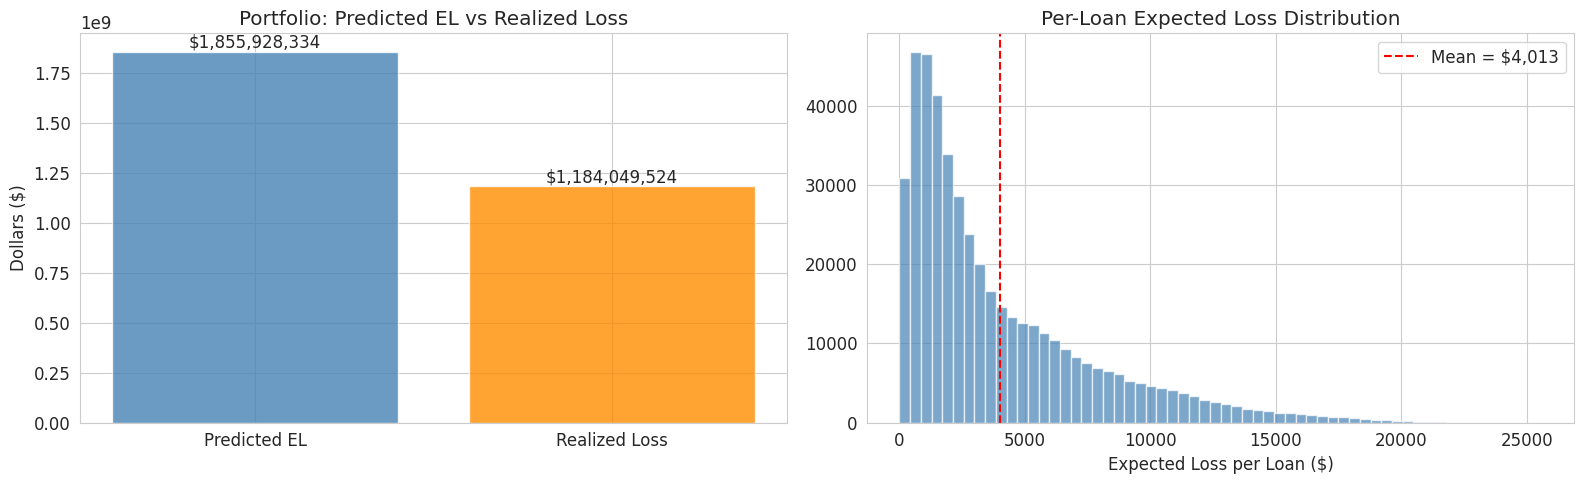

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(['Predicted EL', 'Realized Loss'], [total_el, total_realized],
            color=['steelblue', 'darkorange'], alpha=0.8)
axes[0].set_ylabel('Dollars ($)')
axes[0].set_title('Portfolio: Predicted EL vs Realized Loss')
for i, v in enumerate([total_el, total_realized]):
    axes[0].text(i, v, f'\${v:,.0f}', ha='center', va='bottom')

axes[1].hist(results['expected_loss'], bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(results['expected_loss'].mean(), color='red', linestyle='--',
                label=f"Mean = \${results['expected_loss'].mean():,.0f}")
axes[1].set_xlabel('Expected Loss per Loan ($)')
axes[1].set_title('Per-Loan Expected Loss Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Risk Segmentation by Sub-Grade

           count  total_exposure  avg_pd  avg_ead  avg_lgd       total_el  total_realized  el_rate  realized_rate
sub_grade                                                                                                        
A1         18752  265707425.0000  0.0991   0.5806   0.9247  13963307.0687    5670804.2240   0.0526         0.0213
A2         12348  163105850.0000  0.1343   0.5824   0.9280  11745850.8495    5517378.6408   0.0720         0.0338
A3         11907  156486600.0000  0.1599   0.5823   0.9295  13368642.3182    7085132.7318   0.0854         0.0453
A4         14963  208350475.0000  0.1993   0.5861   0.9309  22122601.2789   10853792.6297   0.1062         0.0521
A5         17875  247806200.0000  0.2414   0.5924   0.9301  33308890.5137   16469815.1829   0.1344         0.0665
B1         25326  330888125.0000  0.2797   0.5955   0.9297  53203727.5847   27767826.0827   0.1608         0.0839
B2         24150  311412575.0000  0.3151   0.5970   0.9300  57409646.3927   27146148.712

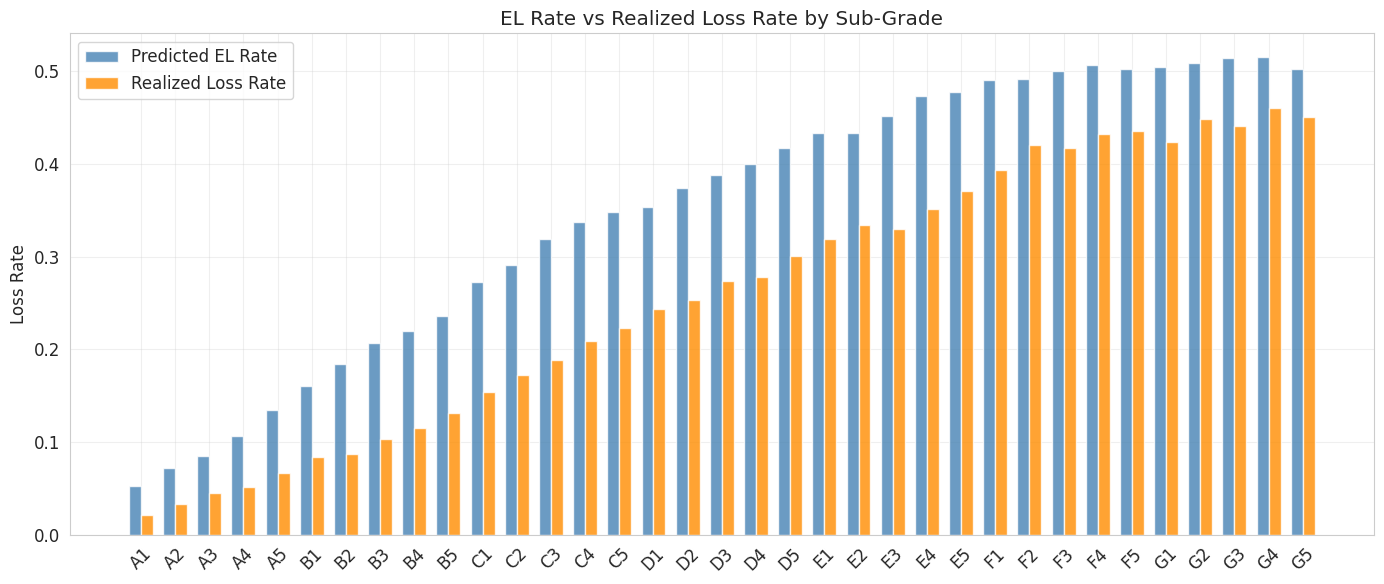

In [47]:
grade_labels = {i: sg for i, sg in enumerate(sub_grades)}
results['sub_grade'] = results['grade_sub'].map(grade_labels)

seg = results.groupby('sub_grade').agg(
    count=('loan_amnt', 'count'),
    total_exposure=('loan_amnt', 'sum'),
    avg_pd=('pd_pred', 'mean'),
    avg_ead=('ead_pred', 'mean'),
    avg_lgd=('lgd_pred', 'mean'),
    total_el=('expected_loss', 'sum'),
    total_realized=('realized_loss', 'sum'),
).reindex(sub_grades)

seg['el_rate'] = seg['total_el'] / seg['total_exposure']
seg['realized_rate'] = seg['total_realized'] / seg['total_exposure']

print(seg.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(seg))
width = 0.35
ax.bar(x - width/2, seg['el_rate'], width, label='Predicted EL Rate', color='steelblue', alpha=0.8)
ax.bar(x + width/2, seg['realized_rate'], width, label='Realized Loss Rate', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(seg.index, rotation=45)
ax.set_ylabel('Loss Rate')
ax.set_title('EL Rate vs Realized Loss Rate by Sub-Grade')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save Portfolio Output

In [48]:
import os
os.makedirs('../models', exist_ok=True)
os.makedirs('../data', exist_ok=True)

results.to_csv('../data/expected_loss_test_2016_2017.csv', index=False)

summary = {
    'population': 'Test vintage 2016-2017, all loans',
    'n_loans': int(len(results)),
    'total_exposure': float(total_exposure),
    'total_expected_loss': float(total_el),
    'el_rate': float(el_rate),
    'total_realized_loss': float(total_realized),
    'realized_loss_rate': float(realized_rate),
    'pd_model': 'XGBoost (AUC 0.7251)',
    'ead_model': 'Mean-by-term lookup',
    'lgd_model': 'LightGBM (R2 0.0095)',
}
with open('../models/expected_loss_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("  ../data/expected_loss_test_2016_2017.csv")
print("  ../models/expected_loss_summary.json")

Saved:
  ../data/expected_loss_test_2016_2017.csv
  ../models/expected_loss_summary.json


## 10. Summary

**Population:** 462,426 loans, test vintage 2016–2017, scored fresh from raw data so PD/EAD/LGD all see identically-preprocessed rows.

**Formula:** `EL = PD × EAD% × LGD × loan_amnt`

**Component Scores (Test Population):**

| Model | Mean | Min | Max |
|---|---|---|---|
| PD (XGBoost) | 0.4439 | 0.0104 | 0.9578 |
| EAD (term lookup) | 0.6144 | 0.5805 | 0.7348 |
| LGD (LightGBM) | 0.9208 | 0.8320 | 0.9886 |

**Portfolio Results:**

| Metric | Value |
|---|---|
| Total exposure | $6,661,864,075 |
| Total predicted EL | $1,853,773,860 |
| EL rate | 27.83% |
| Total realized loss (actual defaults) | $1,184,049,524 |
| Realized loss rate | 17.77% |
| Predicted vs. realized | 156.6% of realized loss captured |

*Note: these figures were produced before a feature-reconstruction bug fix (a blanket >50%-missing auto-drop was deleting `mths_since_last_delinq`, which the LGD model expects — see Section 2's comment). Re-run after the fix; LGD-driven figures may shift slightly, but the gap described below is structural and will not close.*

**Interpretation:**
- Predicted EL overshoots realized loss by ~57%. This is expected, not a bug: PD (mean 0.44) is calibrated on the whole population including borrowers who are current/paying, but the EL formula multiplies PD × EAD × LGD independently per loan rather than modeling their joint distribution — loans with high predicted PD don't necessarily have correspondingly lower EAD/LGD in reality, so the product overstates the tail. A calibration adjustment (e.g. scaling factor fit on a validation slice) would be a reasonable next step before using this for capital provisioning.
- PD carries essentially all the discriminative power (AUC 0.7251) — EAD and LGD are both close to flat population averages (term lookup; R²≈0.01), so almost all of the loan-to-loan variation in predicted EL is coming from PD alone.
- Risk segmentation by sub-grade (Section 8) should show EL rate rising monotonically from A1 → G5, since PD is strongly grade-ordered and dominates the EL formula.
- The predicted-vs-realized comparison is a sanity check on portfolio-level calibration, not a training metric — a model built on weak EAD/LGD signal can still rank-order risk usefully (for underwriting/pricing decisions) even while overstating absolute dollar loss.